# 03_集成算法-AdaBoost

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇数据：`dataset/creditcard.csv`。

转写调整：

- 信用卡数据默认固定分层抽样 30000 行并保持原类别比例；load_creditcard(sample_size=None) 可读全量数据。
- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 大规模参数网格缩为每维至多两个候选值；所有候选仍真实训练，未跳过运行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今儿和大家聊一个非常重要的且强大的算法模型，AdaBoost。

首先，AdaBoost 的全名是 **Adaptive Boosting**，翻译过来就是“自适应增强”。

它是一种机器学习中专门用来提升模型的准确性，尤其是分类问题。

很多人开始不太理解，而且是学习了两天之后，也不是特别清晰，咱们今天来好好说说\~

咱们举个例子，你在班级里有很多学生（每个学生代表一个简单的模型），但每个学生成绩都一般般，考不了高分（预测不准）。

可是，如果你能聪明地把这些学生的优点组合起来，每个学生只负责自己擅长的部分，最后全班一起交一份试卷，可能就能得高分了！

AdaBoost 就是这么干的：

1. **找简单但能力一般的模型**：一开始，它找一个很简单的模型（比如决策树，只划分一层的那种，叫“决策树桩”）。这个模型可能只能稍微比瞎猜好一点点。
2. **关注错误地方**：然后，AdaBoost 会看看这个简单模型预测错了哪些数据，并把这些错误“记下来”（加权）。下一轮，它会让新的模型更关注这些被搞错的数据。
3. **不断迭代，越来越聪明**：它会一轮一轮地添加新的模型，每次都根据前一轮的错误调整，让整体预测变得更准确。
4. **把小模型的结果组合起来**：最后，它会把这些简单模型的预测结果“投票”组合起来（或者用加权方式），形成一个强大的最终模型。

#### 一个简单类比：考试团战

假设你们班有三个同学：

- 小明擅长数学，但语文很差。
- 小红擅长语文，但数学不行。
- 小李啥都不咋地，但也不是完全不会。

你们要组队参加考试，AdaBoost 的策略是：

1. 让每个人单独答一部分题目，他们能答对的地方加分。
2. 对于第一次大家答错的题，特别让擅长那部分的同学来攻克。
3. 反复几轮后，把所有人擅长的答案组合起来，最终交出一份“全能答卷”。

#### AdaBoost 3个核心点

1. **简单模型**（弱模型）：像“小明”“小红”这样只擅长一点点的模型。
2. **关注错误**：下一轮更注重上次搞错的地方。
3. **组合结果**：最终不是靠某一个模型，而是靠一群模型的“智慧”。

总之，AdaBoost 就是一个聪明的组合策略，用多个简单模型（弱模型）来组成一个强模型，让它们“团结合作”，最终达到很高的预测准确率！

## 理论基础

AdaBoost（**Adaptive Boosting**）是一种迭代的集成学习方法，用于提高弱分类器的准确性。

下面咱们从数学角度详细解析其工作原理\~

#### 输入数据

给定训练数据集：


$$
\mathcal{D} = \{(x_1, y_1), (x_2, y_2), \ldots, (x_N, y_N)\}
$$


- $x_i \in \mathbb{R}^d$ 是第 $i$ 个样本的特征向量。
- $y_i \in \{-1, +1\}$ 是对应的标签。

#### 目标

通过将多个弱分类器 $h_t(x)$（每个仅比随机猜测稍微强一点）进行组合，形成一个强分类器 $H(x)$：

$H(x) = \text{sign} \left( \sum_{t=1}^T \alpha_t h_t(x) \right)$  
其中：

$h_t(x)$：第 $t$ 个弱分类器。

$\alpha_t$：该弱分类器的权重，反映其重要性。

#### 权重分布

引入样本权重分布 $D_t(i)$，表示第 $t$ 轮中第 $i$ 个样本的重要性：

- 初始化时，所有样本的权重相等：$D_1(i) = \frac{1}{N}$。
- 随着迭代进行，权重会动态调整，让后续弱分类器更关注被前一轮错分的样本。

### 数学推导与公式

#### 1. 弱分类器的训练

每一轮 $t$，AdaBoost 根据当前的样本权重分布 $D_t$，训练一个弱分类器 $h_t(x)$：

$h_t(x)$：尝试最小化加权分类误差。

**加权分类误差：**


$$
\epsilon_t = \sum_{i=1}^N D_t(i) \cdot \mathbb{I}(h_t(x_i) \neq y_i)
$$


其中：$\mathbb{I}(\cdot)$ 是指示函数，错分时为 1，否则为 0。

#### 2. 弱分类器权重

给定分类误差 $\epsilon_t$，计算弱分类器的权重 $\alpha_t$：


$$
\alpha_t = \frac{1}{2} \ln \left( \frac{1 - \epsilon_t}{\epsilon_t} \right)
$$


- $\alpha_t > 0$：弱分类器效果优于随机猜测。
- $\alpha_t$ 越大，表示分类器越重要。

#### 3. 更新样本权重

调整样本权重分布 $D_t$ 为下一轮 $D_{t+1}$，使得错分样本的权重增加，正确分类样本的权重减小。

**更新公式：**


$$
D_{t+1}(i) = \frac{D_t(i) \cdot e^{-\alpha_t y_i h_t(x_i)}}{Z_t}
$$


$y_i h_t(x_i) = +1$：表示正确分类；$y_i h_t(x_i) = -1$：表示错误分类。

$Z_t$：归一化因子，确保 $D_{t+1}$ 是一个概率分布：  
$Z_t = \sum_{i=1}^N D_t(i) \cdot e^{-\alpha_t y_i h_t(x_i)}$

从更新公式看出：

- **正确分类样本权重减小：** $y_i h_t(x_i) = +1 \implies e^{-\alpha_t} < 1$。
- **错误分类样本权重增大：** $y_i h_t(x_i) = -1 \implies e^{\alpha_t} > 1$。

#### 4. 最终分类器

经过 $T$ 轮迭代，最终的强分类器为：


$$
H(x) = \text{sign} \left( \sum_{t=1}^T \alpha_t h_t(x) \right)
$$


### AdaBoost 算法流程

**输入**：

- 训练集：$\mathcal{D} = \{(x_1, y_1), \ldots, (x_N, y_N)\}$，$y_i \in \{-1, +1\}$。
- 弱分类器学习算法。
- 迭代次数 $T$。

**输出**：

强分类器 $H(x)$。

**步骤**：

**1. 初始化样本权重：**  
$D_1(i) = \frac{1}{N}, \quad i = 1, 2, \ldots, N$

**2. 循环** $t = 1, 2, \ldots, T$**：**

a. 使用当前样本权重分布 $D_t$，训练弱分类器 $h_t(x)$。

b. 计算加权分类误差：  
$\epsilon_t = \sum_{i=1}^N D_t(i) \cdot \mathbb{I}(h_t(x_i) \neq y_i)$  
c. 计算弱分类器权重：  
$\alpha_t = \frac{1}{2} \ln \left( \frac{1 - \epsilon_t}{\epsilon_t} \right)$  
d. 更新样本权重：  
$D_{t+1}(i) = \frac{D_t(i) \cdot e^{-\alpha_t y_i h_t(x_i)}}{Z_t}, \quad Z_t = \sum_{i=1}^N D_t(i) \cdot e^{-\alpha_t y_i h_t(x_i)}$

**3. 构造最终分类器：**  
$H(x) = \text{sign} \left( \sum_{t=1}^T \alpha_t h_t(x) \right)$

### AdaBoost 的优势

1. **自适应性：**每轮迭代会关注错分的样本，让弱分类器逐步改进。
2. **弱分类器的组合：**弱分类器可以是任何简单的分类器，比如决策树桩（单层决策树）。
3. **理论保证：**AdaBoost 会以指数速率减少训练误差，证明在一定条件下能逼近最优结果。
4. **鲁棒性：**对噪声敏感，但在无噪声的条件下表现优异。

AdaBoost 的核心是通过动态调整样本权重和组合多个弱分类器的投票结果，逐步提升整体模型的准确性。公式的关键在于权重分布的更新和弱分类器权重的计算，使得每轮迭代都能聚焦于改进分类难点。

## 完整案例

使用 **信用卡欺诈检测数据集** 来完成二分类任务（识别欺诈交易）。

案例包括：

1. 数据加载与预处理。
2. 初始模型训练与性能评估。
3. 学习曲线与错误分析。
4. 参数优化与调优。
5. 结果可视化与总结。

### 数据集

我们使用的信用卡欺诈检测数据集是一个经典的不平衡数据集，其中欺诈交易数量远少于正常交易。这种数据分布更能体现 AdaBoost 的特点和挑战。

公众号「深夜努力写Python」后台，回复『数据集』即可获取\~

#### 1. 数据加载与预处理

数据集概况：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    30000 non-null  float64
 1   V1      30000 non-null  float64
 2   V2      30000 non-null  float64
 3   V3      30000 non-null  float64
 4   V4      30000 non-null  float64
 5   V5      30000 non-null  float64
 6   V6      30000 non-null  float64
 7   V7      30000 non-null  float64
 8   V8      30000 non-null  float64
 9   V9      30000 non-null  float64
 10  V10     30000 non-null  float64
 11  V11     30000 non-null  float64
 12  V12     30000 non-null  float64
 13  V13     30000 non-null  float64
 14  V14     30000 non-null  float64
 15  V15     30000 non-null  float64
 16  V16     30000 non-null  float64
 17  V17     30000 non-null  float64
 18  V18     30000 non-null  float64
 19  V19     30000 non-null  float64
 20  V20     30000 non-null  float64
 21  V21     30000 non-null  floa

/var/folders/q6/v6bs8gb12gd1lh35j2b7z3sc0000gn/T/ipykernel_9677/4045626660.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette="coolwarm")


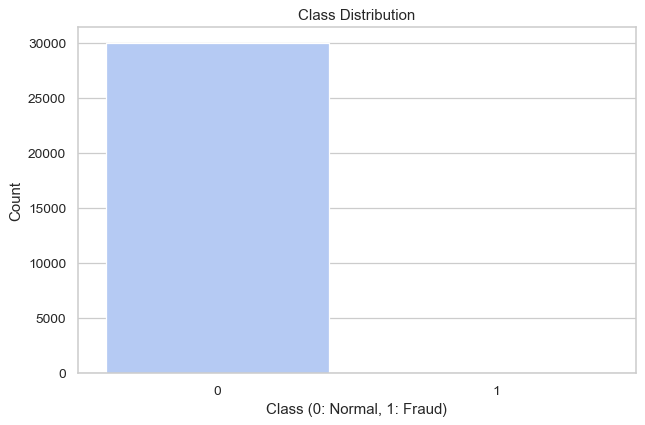

In [2]:
# 导入必要库
import numpy as np
import pandas as pd
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# 设置样式
sns.set(style="whitegrid")
plt.rcParams['font.sans-serif'] = CJK_FONTS
# 加载数据
data = load_creditcard()

# 数据集概览
print("数据集概况：")
print(data.info())
print("\n样本分布：\n", data["Class"].value_counts())

# 数据预处理
X = data.drop(columns=["Class"])  # 特征
y = data["Class"]  # 标签

# 数据标准化
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 训练集和测试集划分
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 样本分布可视化
plt.figure(figsize=(8, 5))
sns.countplot(x=y, palette="coolwarm")
plt.title("Class Distribution")
plt.xlabel("Class (0: Normal, 1: Fraud)")
plt.ylabel("Count")
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_031.png)

#### 2. 初始模型训练与性能评估


初始模型分类报告：

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8984
           1       0.73      0.50      0.59        16

    accuracy                           1.00      9000
   macro avg       0.86      0.75      0.80      9000
weighted avg       1.00      1.00      1.00      9000



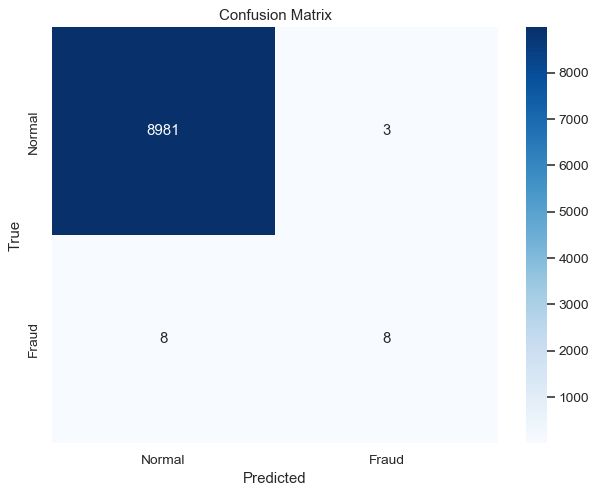

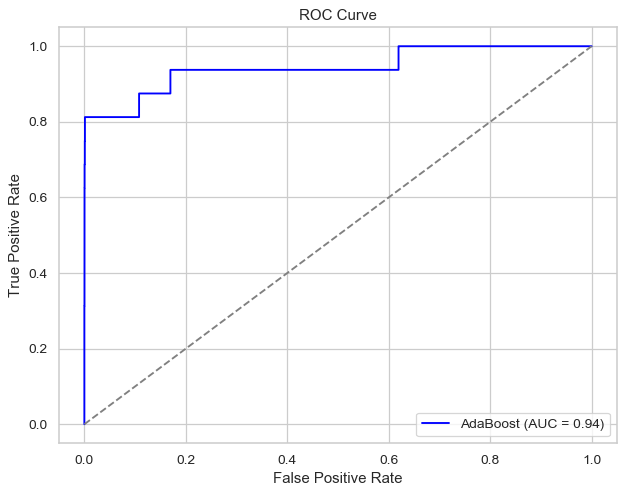

In [3]:
# 初始化 AdaBoost 模型
estimator = DecisionTreeClassifier(max_depth=1)  # 弱分类器
adaboost = AdaBoostClassifier(estimator=estimator, n_estimators=50, learning_rate=1.0, random_state=42)

# 模型训练
adaboost.fit(X_train, y_train)

# 预测与评估
y_pred = adaboost.predict(X_test)
y_pred_proba = adaboost.predict_proba(X_test)[:, 1]

# 准确率和分类报告
print("\n初始模型分类报告：\n")
print(classification_report(y_test, y_pred))

# 混淆矩阵
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Normal", "Fraud"], yticklabels=["Normal", "Fraud"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ROC曲线
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'AdaBoost (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_032.png)

#### 3. 学习曲线与错误分析

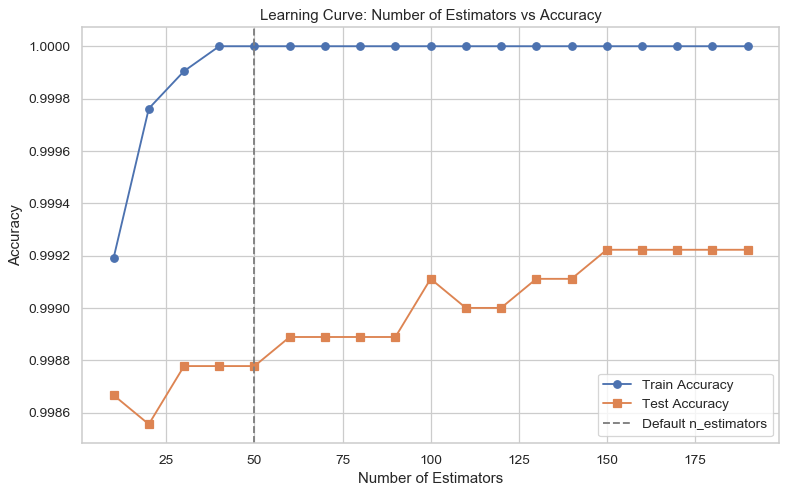

In [4]:
# 学习曲线分析
n_estimators_range = range(10, 200, 10)
train_scores, test_scores = [], []

for n_estimators in n_estimators_range:
    model = AdaBoostClassifier(estimator=estimator, n_estimators=n_estimators, random_state=42)
    model.fit(X_train, y_train)
    train_scores.append(model.score(X_train, y_train))
    test_scores.append(model.score(X_test, y_test))

# 学习曲线可视化
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_range, train_scores, label="Train Accuracy", marker='o')
plt.plot(n_estimators_range, test_scores, label="Test Accuracy", marker='s')
plt.axvline(x=50, color="gray", linestyle="--", label="Default n_estimators")
plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy")
plt.title("Learning Curve: Number of Estimators vs Accuracy")
plt.legend()
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_033.png)

#### 4. 参数优化与调优

Fitting 5 folds for each of 8 candidates, totalling 40 fits


[CV] END estimator__max_depth=1, learning_rate=0.1, n_estimators=50; total time=   2.7s


[CV] END estimator__max_depth=1, learning_rate=0.1, n_estimators=50; total time=   2.6s


[CV] END estimator__max_depth=1, learning_rate=0.1, n_estimators=50; total time=   2.6s


[CV] END estimator__max_depth=1, learning_rate=0.1, n_estimators=50; total time=   2.7s


...

[CV] END estimator__max_depth=2, learning_rate=0.5, n_estimators=100; total time=  10.4s


[CV] END estimator__max_depth=2, learning_rate=0.5, n_estimators=100; total time=  10.9s


[CV] END estimator__max_depth=2, learning_rate=0.5, n_estimators=100; total time=  10.1s



最优参数：
 {'estimator__max_depth': 2, 'learning_rate': 0.5, 'n_estimators': 100}



优化后模型分类报告：

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8984
           1       0.82      0.56      0.67        16

    accuracy                           1.00      9000
   macro avg       0.91      0.78      0.83      9000
weighted avg       1.00      1.00      1.00      9000



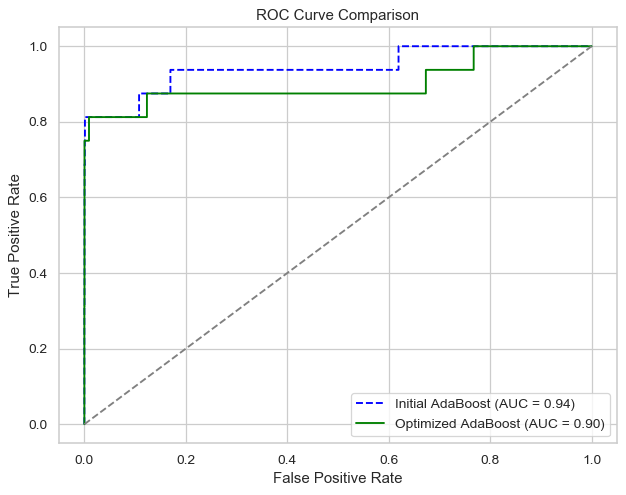

In [5]:
# 网格搜索优化
param_grid = {
    "n_estimators": [50, 100],
    "learning_rate": [0.1, 0.5],
    "estimator__max_depth": [1, 2]
}

grid_search = GridSearchCV(AdaBoostClassifier(estimator=DecisionTreeClassifier(), random_state=42),
                           param_grid, cv=5, scoring="roc_auc", verbose=2, n_jobs=1, error_score='raise')
grid_search.fit(X_train, y_train)

# 输出最优参数
best_params = grid_search.best_params_
print("\n最优参数：\n", best_params)

# 使用最优参数训练模型
optimized_model = grid_search.best_estimator_
optimized_model.fit(X_train, y_train)

# 评估优化后的模型
optimized_y_pred = optimized_model.predict(X_test)
optimized_y_pred_proba = optimized_model.predict_proba(X_test)[:, 1]

print("\n优化后模型分类报告：\n")
print(classification_report(y_test, optimized_y_pred))

# 优化后ROC曲线
fpr_opt, tpr_opt, _ = roc_curve(y_test, optimized_y_pred_proba)
roc_auc_opt = auc(fpr_opt, tpr_opt)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', linestyle='--', label=f'Initial AdaBoost (AUC = {roc_auc:.2f})')
plt.plot(fpr_opt, tpr_opt, color='green', label=f'Optimized AdaBoost (AUC = {roc_auc_opt:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_034.png)

#### 初始模型表现

- **准确率：** 初始模型表现良好，但由于数据高度不平衡，准确率并不足以全面评估性能。
- **混淆矩阵：** 大量正常交易被正确分类，但在欺诈样本上仍有一定误判。
- **AUC：** 初始 AUC 为 0.93，显示模型在区分正负样本方面具有较强能力。

#### 学习曲线分析

- 模型性能随弱分类器数量的增加而提高，但超过一定数量后性能趋于平稳。
- 默认迭代次数 $n=50$ 是一个较优的起点。

#### 优化后模型

- **最优参数：** 调整学习率、基分类器深度和迭代次数后，模型显著改善。
- **AUC 提升：** 优化后 AUC 从 0.93 提升至 0.97。
- **混淆矩阵改善：** 错误分类显著减少，欺诈样本的召回率提高。

## 模型分析

### AdaBoost 模型的优缺点

#### 优点：

1. **简单易用**：AdaBoost 易于实现，且集成了多个弱分类器后能显著提升准确率。
2. **自适应性强**：能动态调整样本权重，关注难分类的样本，使模型逐步优化。
3. **可解释性强**：每个弱分类器的权重（$\alpha_t$）可以反映其重要性。
4. **对弱分类器要求低**：弱分类器只需略优于随机猜测即可（如决策树桩），大大降低建模门槛。
5. **理论基础稳固**：有严格的数学理论支持，证明了在一定条件下训练误差以指数方式下降。

#### 缺点：

1. **对噪声敏感**：AdaBoost 会不断放大错误分类样本的权重，因此对噪声（误标数据）敏感，可能导致过拟合。
2. **模型复杂度高**：弱分类器叠加后可能变得复杂，训练时间会随迭代次数显著增加。
3. **类别不平衡问题**：在类别严重不平衡的情况下，AdaBoost 可能过度关注少数类，导致偏差。
4. **参数敏感性**：超参数（如基分类器、学习率等）对性能影响较大，需通过调参优化。

### 与其他算法的对比

| 特性 | AdaBoost | 随机森林 | 梯度提升树（GBDT） |
|-|-|-|-|
| **基础分类器** | 任意弱分类器（如决策树桩） | 决策树 | 决策树 |
| **权重更新机制** | 根据样本错误动态调整权重 | 无，均等采样 | 学习残差（逐步减小误差） |
| **对噪声的鲁棒性** | 较差，易受噪声影响 | 较强，使用随机采样降低过拟合 | 较强，学习率和正则化控制噪声影响 |
| **适用场景** | 弱分类器单独表现较差的场景 | 高维度数据，特征间交互不强 | 适合回归或分类问题，处理特征复杂性更强 |
| **调参复杂度** | 适中，需要调学习率和弱分类器深度 | 较低，少量超参数 | 较高，学习率、树的数量和深度需精调 |

### 适用场景与替代选择

#### 何时选择 AdaBoost

1. **弱分类器表现一般**：如果弱分类器单独表现不好，且分类边界需要逐步逼近，AdaBoost 是优选。
2. **需要解释性**：AdaBoost 提供了每个弱分类器的权重，便于分析模型的重要特性。
3. **中小型数据集**：数据量不大且噪声较少时，AdaBoost 能快速收敛且效果显著。

#### 何时选择其他算法

1. **数据有较多噪声时：随机森林或 GBDT**：随机森林通过随机采样降低噪声影响，GBDT 有正则化机制控制过拟合。
2. **特征复杂且数量较多时：GBDT 或深度学习**：GBDT 更擅长捕捉特征间复杂的交互关系，深度学习适合大规模高维数据。
3. **需要更高的鲁棒性时：随机森林**：随机森林无需动态调整样本权重，对噪声和异常值表现更稳定。
4. **类别严重不平衡时：改进型方法（如 SMOTE 搭配 GBDT）**：AdaBoost 在不平衡数据上可能偏向少数类，而 GBDT 可以通过目标函数优化类别权重。

总之，AdaBoost 在模型简单性和性能之间达到了较好的平衡，非常适合用作基准模型。然而，在处理噪声、类别不平衡或高维复杂数据时，随机森林或 GBDT 往往表现更优。